In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf

In [2]:
years = range(1997, 2026)
for year in years:
    exec(f"data_{year} = pd.read_csv(f'../hw4/data/data-{year}.csv')")

#merged
dfs = []
for year in years:
    df = pd.read_csv(f'../hw4/data/data-{year}.csv')
    dfs.append(df)

# Concatenate into one DataFrame
data = pd.concat(dfs, ignore_index=True)

In [3]:
filtered = data[(data["year"] >= 2009) & (data["year"] <= 2019)]

In [4]:
filtered.head()

,provider_number,fy_start,fy_end,date_processed,date_created,data_source,beds,tot_charges,net_pat_rev,tot_discounts,...,pps_mcare_cost,pps_pgm_cost,hvbp_payment,hrrp_payment,tot_uncomp_care_charges,tot_uncomp_care_partial_pmts,bad_debt,depr_HIT,year,source
64237,10001,2008-10-01,2009-09-30,2010-11-03,2010-10-25,v1996,370.0,980776069.0,236050709.0,744725360.0,...,63056178.0,58133433.0,NaN,NaN,NaN,NaN,NaN,NaN,2009,unique reports
64238,10005,2008-10-01,2009-09-30,2010-05-25,2010-05-21,v1996,114.0,184944919.0,64274300.0,120670619.0,...,13609924.0,11232828.0,NaN,NaN,NaN,NaN,NaN,NaN,2009,unique reports
64239,10006,2008-07-01,2009-06-30,2013-02-19,2012-10-16,v1996,369.0,655289596.0,132795428.0,522494168.0,...,48540830.0,45180064.0,NaN,NaN,NaN,NaN,NaN,NaN,2009,unique reports
64240,10007,2008-10-01,2009-09-30,2013-05-30,2013-05-21,v1996,78.0,49087280.0,15577782.0,33509498.0,...,5790742.0,5252367.0,NaN,NaN,NaN,NaN,NaN,NaN,2009,unique reports
64241,10008,2009-01-01,2009-12-31,2010-06-11,2010-06-10,v1996,29.0,25498474.0,9647437.0,15851037.0,...,1542401.0,1424410.0,NaN,NaN,NaN,NaN,NaN,NaN,2009,unique reports


### Question 1

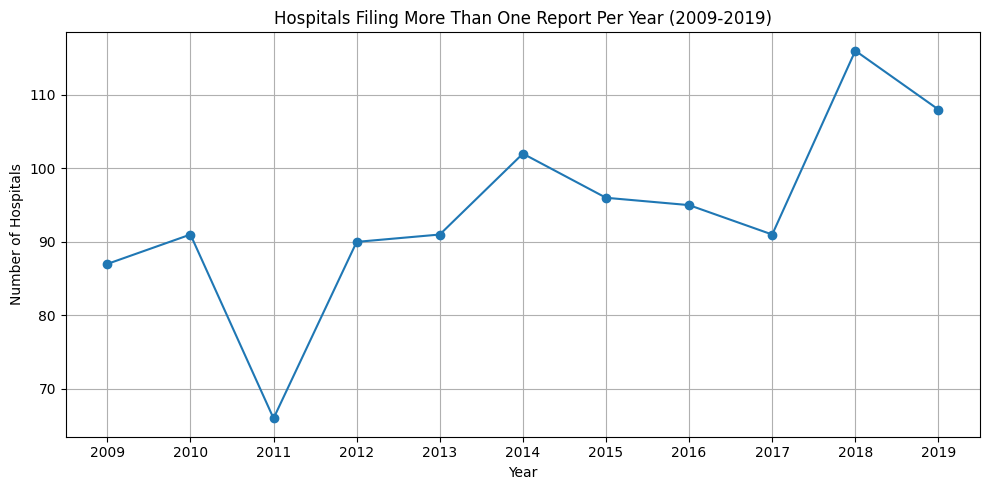

In [5]:
multi = filtered[(filtered['source'] != 'unique reports') & 
              (filtered['year'] >= 2009) & 
              (filtered['year'] <= 2019)]

result = multi.groupby('year')['provider_number'].nunique().reset_index()
result.columns = ['year', 'num_hospitals']

plt.figure(figsize=(10, 5))
plt.plot(result['year'], result['num_hospitals'], marker='o')
plt.title('Hospitals Filing More Than One Report Per Year (2009-2019)')
plt.xlabel('Year')
plt.ylabel('Number of Hospitals')
plt.xticks(result['year'])
plt.grid(True)
plt.tight_layout()
plt.show()

### Question 2

In [6]:
filtered['provider_number'].nunique()

6897

### Question 3

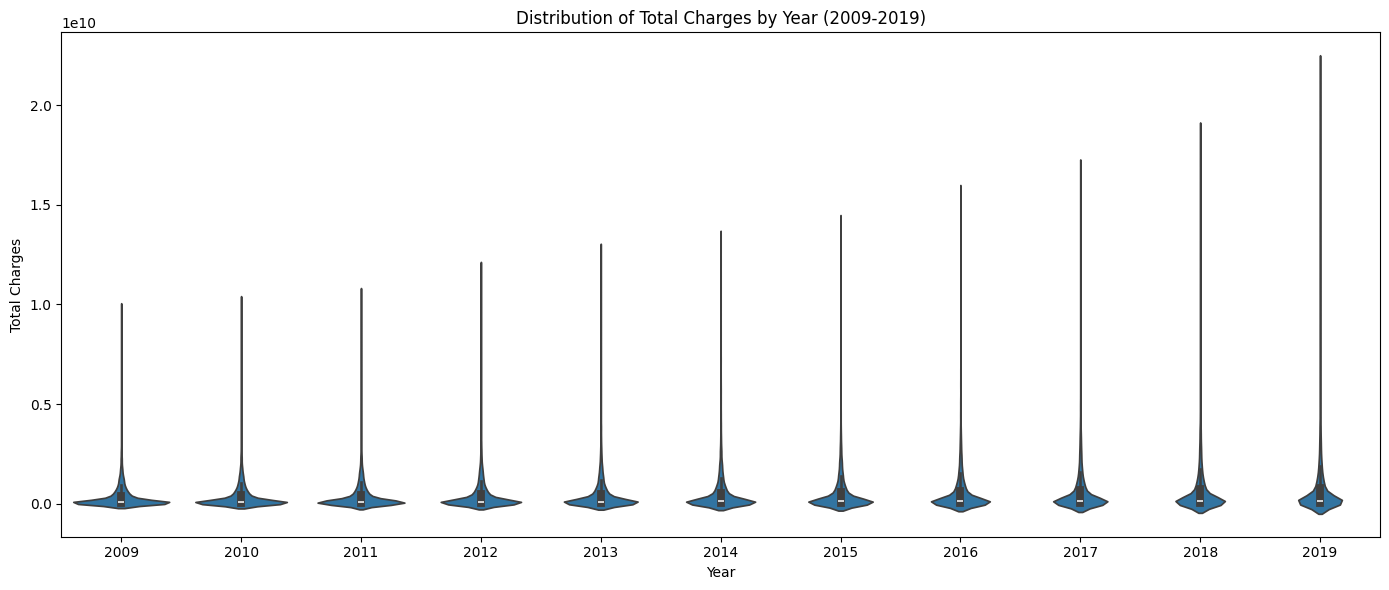

In [7]:
plt.figure(figsize=(14, 6))
sns.violinplot(data=filtered, x='year', y='tot_charges')

filtered = filtered[filtered['tot_charges'] > 0]
filtered = filtered[filtered['tot_charges'] < filtered['tot_charges'].quantile(0.99)]

plt.title('Distribution of Total Charges by Year (2009-2019)')
plt.xlabel('Year')
plt.ylabel('Total Charges')
plt.tight_layout()
plt.show()

### Question 4

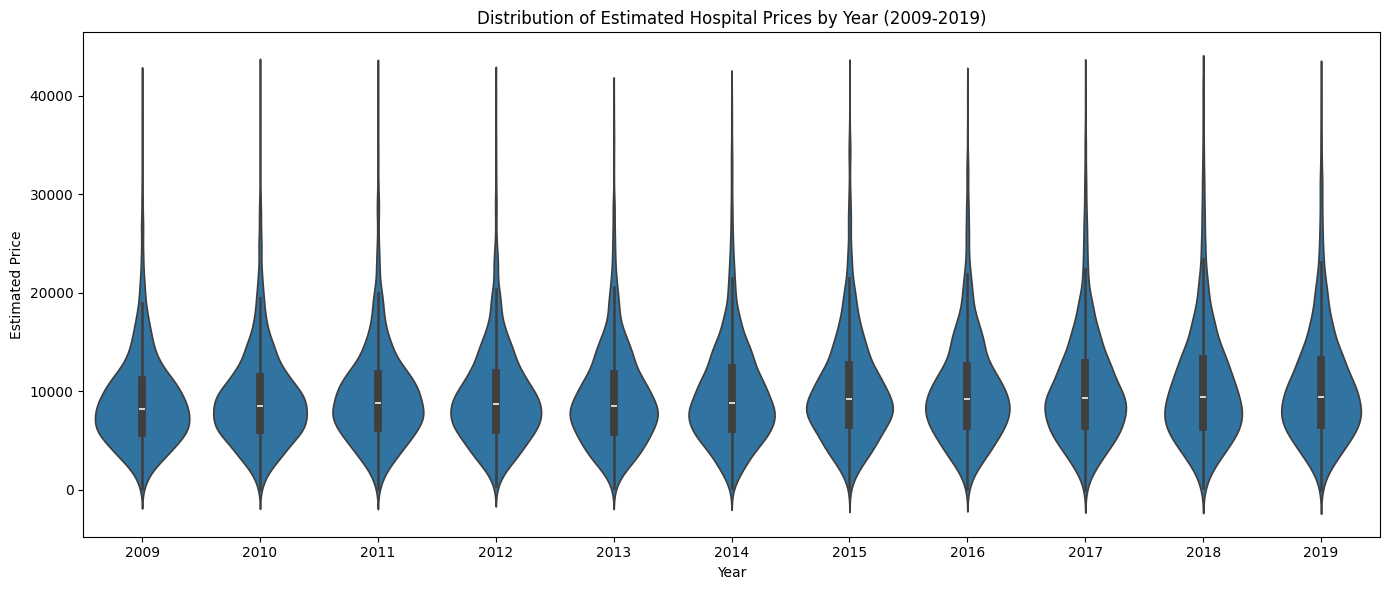

In [8]:
filtered['discount_factor'] = 1 - filtered['tot_discounts'] / filtered['tot_charges']
filtered['price_num'] = (filtered['ip_charges'] + filtered['icu_charges'] + filtered['ancillary_charges']) * filtered['discount_factor'] - filtered['tot_mcare_payment']
filtered['price_denom'] = filtered['tot_discharges'] - filtered['mcare_discharges']
filtered['price'] = filtered['price_num'] / filtered['price_denom']

filtered = filtered[filtered['price'] > 0]
filtered = filtered[filtered['price'] < filtered['price'].quantile(0.99)]

plt.figure(figsize=(14, 6))
sns.violinplot(data=filtered, x='year', y='price')
plt.title('Distribution of Estimated Hospital Prices by Year (2009-2019)')
plt.xlabel('Year')
plt.ylabel('Estimated Price')
plt.tight_layout()
plt.show()

### Question 5

/tmp/ipykernel_533775/2373061695.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filt['penalize'] = (filt['hrrp_payment'] < 0) | (filt['hvbp_payment'] < 0)


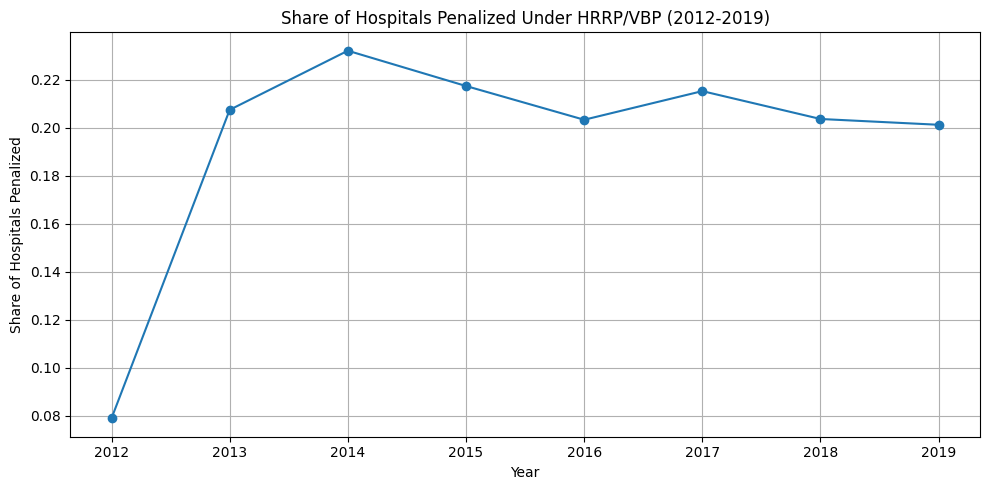

In [9]:
filt = data[(data["year"] >= 2012) & (data["year"] <= 2019)]
filt['penalize'] = (filt['hrrp_payment'] < 0) | (filt['hvbp_payment'] < 0)

result = filt.groupby('year')['penalize'].mean().reset_index()
result.columns = ['year', 'share_penalized']

plt.figure(figsize=(10, 5))
plt.plot(result['year'], result['share_penalized'], marker='o')
plt.title('Share of Hospitals Penalized Under HRRP/VBP (2012-2019)')
plt.xlabel('Year')
plt.ylabel('Share of Hospitals Penalized')
plt.xticks(result['year'])
plt.grid(True)
plt.tight_layout()
plt.show()

### Question 6

In [10]:
from statsmodels.iolib.summary2 import summary_col

def calc_price(df):
    df = df.copy()
    df['discount_factor'] = 1 - df['tot_discounts'] / df['tot_charges']
    df['price_num'] = (df['ip_charges'] + df['icu_charges'] + df['ancillary_charges']) * df['discount_factor'] - df['tot_mcare_payment']
    df['price_denom'] = df['tot_discharges'] - df['mcare_discharges']
    df['price'] = df['price_num'] / df['price_denom']
    return df

price_2011 = calc_price(filtered[filtered['year'] == 2011])[['provider_number', 'price']].rename(columns={'price': 'price_2011'})
price_2014 = calc_price(filtered[filtered['year'] == 2014])[['provider_number', 'price']].rename(columns={'price': 'price_2014'})
price_change = price_2011.merge(price_2014, on='provider_number')
price_change['price_change'] = price_change['price_2014'] - price_change['price_2011']

pen_2012 = filtered[filtered['year'] == 2012][['provider_number', 'hrrp_payment', 'hvbp_payment']].copy()
pen_2012['hrrp_payment'] = pen_2012['hrrp_payment'].fillna(0)
pen_2012['hvbp_payment'] = pen_2012['hvbp_payment'].fillna(0)
pen_2012['net_penalty'] = pen_2012['hrrp_payment'] + pen_2012['hvbp_payment']

# Pre-2012 
pre = filtered[(filtered['year'] >= 2009) & (filtered['year'] <= 2011)]
pre_avg = pre.groupby('provider_number').agg(
    avg_mcare_discharges=('mcare_discharges', 'mean'),
    avg_beds=('beds', 'mean'),
    avg_mcaid_discharges=('mcaid_discharges', 'mean')
).reset_index()

# merge
df_iv = price_change.merge(pen_2012[['provider_number', 'net_penalty']], on='provider_number')
df_iv = df_iv.merge(pre_avg, on='provider_number')

# clean
df_iv = df_iv[df_iv['price_2011'] > 0]
df_iv = df_iv[df_iv['price_2014'] > 0]
df_iv = df_iv[df_iv['price_change'].between(df_iv['price_change'].quantile(0.01), df_iv['price_change'].quantile(0.99))]

# reg
ols1 = smf.ols('price_change ~ net_penalty', data=df_iv).fit()
ols2 = smf.ols('price_change ~ net_penalty + avg_beds', data=df_iv).fit()
ols3 = smf.ols('price_change ~ net_penalty + avg_beds + avg_mcaid_discharges', data=df_iv).fit()

table = summary_col(
    [ols1, ols2, ols3],
    stars=True,
    model_names=['Baseline', 'Baseline + Beds', 'Baseline + Beds + Medicaid'],
    info_dict={'N': lambda x: f"{int(x.nobs):,}", 'R²': lambda x: f"{x.rsquared:.3f}"}
)

print(table)


                       Baseline  Baseline + Beds Baseline + Beds + Medicaid
---------------------------------------------------------------------------
Intercept            221.1150*** 204.7256***     90.3602                   
                     (46.1546)   (46.5883)       (58.2699)                 
net_penalty          0.0013      0.0013          0.0011                    
                     (0.0017)    (0.0016)        (0.0017)                  
avg_beds                         0.0692**        0.0637**                  
                                 (0.0282)        (0.0283)                  
avg_mcaid_discharges                             0.0754***                 
                                                 (0.0234)                  
R-squared            0.0003      0.0028          0.0072                    
R-squared Adj.       -0.0001     0.0020          0.0059                    
N                    2,366       2,366           2,358                     
R²         

### Question 7

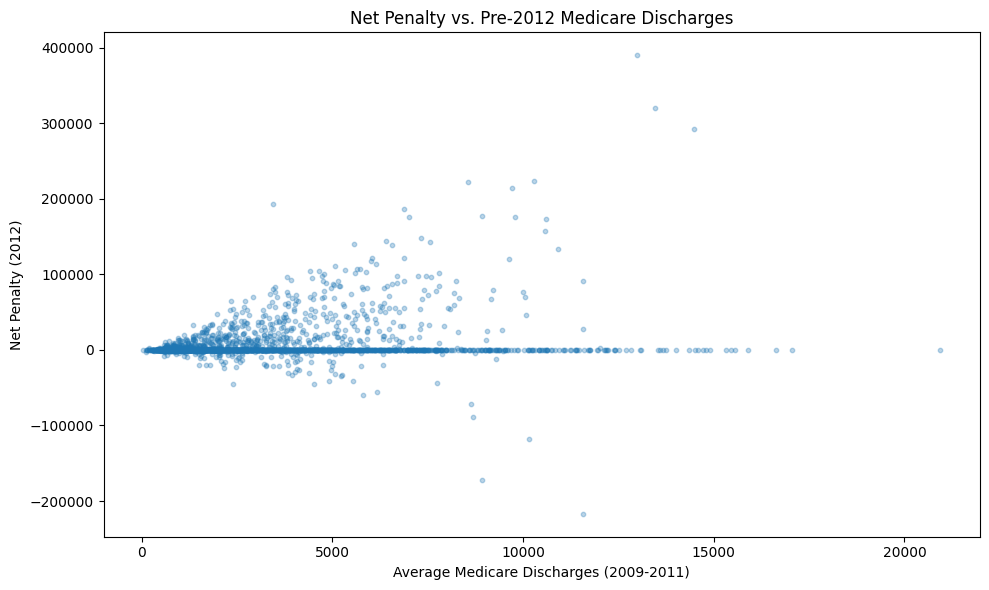

In [11]:
plt.figure(figsize=(10, 6))
plt.scatter(df_iv['avg_mcare_discharges'], df_iv['net_penalty'], alpha=0.3, s=10)
plt.title('Net Penalty vs. Pre-2012 Medicare Discharges')
plt.xlabel('Average Medicare Discharges (2009-2011)')
plt.ylabel('Net Penalty (2012)')
plt.tight_layout()
plt.show()

### Question 8

In [12]:
# --- First Stage ---
fs1 = smf.ols('net_penalty ~ avg_mcare_discharges', data=df_iv).fit()
fs2 = smf.ols('net_penalty ~ avg_mcare_discharges + avg_beds', data=df_iv).fit()
fs3 = smf.ols('net_penalty ~ avg_mcare_discharges + avg_beds + avg_mcaid_discharges', data=df_iv).fit()

# --- Reduced Form ---
rf1 = smf.ols('price_change ~ avg_mcare_discharges', data=df_iv).fit()
rf2 = smf.ols('price_change ~ avg_mcare_discharges + avg_beds', data=df_iv).fit()
rf3 = smf.ols('price_change ~ avg_mcare_discharges + avg_beds + avg_mcaid_discharges', data=df_iv).fit()

In [13]:
table_fs = summary_col(
    [fs1, fs2, fs3],
    stars=True,
    model_names=['Baseline', 'Baseline + Beds', 'Baseline + Beds + Medicaid'],
    info_dict={'N': lambda x: f"{int(x.nobs):,}", 'R²': lambda x: f"{x.rsquared:.3f}"}
)
table_fs.add_title("First Stage")
print(table_fs)

                               First Stage
                      Baseline  Baseline + Beds Baseline + Beds + Medicaid
--------------------------------------------------------------------------
Intercept            264.4470   272.7500        667.1467                  
                     (863.9734) (864.5272)      (877.1353)                
avg_mcare_discharges 2.0582***  2.0635***       2.3564***                 
                     (0.1947)   (0.1954)        (0.2216)                  
avg_beds                        -0.1105         -0.0865                   
                                (0.3454)        (0.3455)                  
avg_mcaid_discharges                            -0.9131***                
                                                (0.3229)                  
R-squared            0.0451     0.0452          0.0483                    
R-squared Adj.       0.0447     0.0444          0.0471                    
N                    2,366      2,366           2,358    

In [14]:
table_rf = summary_col(
    [rf1, rf2, rf3],
    stars=True,
    model_names=['Baseline', 'Baseline + Beds', 'Baseline + Beds + Medicaid'],
    info_dict={'N': lambda x: f"{int(x.nobs):,}", 'R²': lambda x: f"{x.rsquared:.3f}"}
)
table_rf.add_title("Reduced Form")
print(table_rf)

                               Reduced Form
                       Baseline  Baseline + Beds Baseline + Beds + Medicaid
---------------------------------------------------------------------------
Intercept            197.0303*** 191.8850***     150.7567**                
                     (70.9668)   (70.9262)       (71.8766)                 
avg_mcare_discharges 0.0099      0.0065          -0.0225                   
                     (0.0160)    (0.0160)        (0.0182)                  
avg_beds                         0.0685**        0.0661**                  
                                 (0.0283)        (0.0283)                  
avg_mcaid_discharges                             0.0915***                 
                                                 (0.0265)                  
R-squared            0.0002      0.0026          0.0077                    
R-squared Adj.       -0.0003     0.0018          0.0064                    
N                    2,366       2,366      

### Question 9

In [15]:
iv_coef1 = rf1.params['avg_mcare_discharges'] / fs1.params['avg_mcare_discharges']
iv_coef2 = rf2.params['avg_mcare_discharges'] / fs2.params['avg_mcare_discharges']
iv_coef3 = rf3.params['avg_mcare_discharges'] / fs3.params['avg_mcare_discharges']

print("IV Estimates of net penalty effect on price change:")
print(f"  Baseline:                  {iv_coef1:.4f}")
print(f"  Baseline + Beds:           {iv_coef2:.4f}")
print(f"  Baseline + Beds + Medicaid:{iv_coef3:.4f}")

IV Estimates of net penalty effect on price change:
  Baseline:                  0.0048
  Baseline + Beds:           0.0032
  Baseline + Beds + Medicaid:-0.0096


In [16]:
from linearmodels.iv import IV2SLS

iv1 = IV2SLS.from_formula('price_change ~ 1 + [net_penalty ~ avg_mcare_discharges]', data=df_iv).fit()
iv2 = IV2SLS.from_formula('price_change ~ 1 + avg_beds + [net_penalty ~ avg_mcare_discharges]', data=df_iv).fit()
iv3 = IV2SLS.from_formula('price_change ~ 1 + avg_beds + avg_mcaid_discharges + [net_penalty ~ avg_mcare_discharges]', data=df_iv).fit()


results = {
    'Specification': ['Baseline', 'Baseline + Beds', 'Baseline + Beds + Medicaid'],
    'IV Estimate': [iv_coef1, iv_coef2, iv_coef3]
}

iv_table = pd.DataFrame(results)
iv_table['IV Estimate'] = iv_table['IV Estimate'].round(4)
print(iv_table.to_string(index=False))

             Specification  IV Estimate
                  Baseline       0.0048
           Baseline + Beds       0.0032
Baseline + Beds + Medicaid      -0.0096


/home/jszhao/econ470/a0/pyenv/lib/python3.13/site-packages/linearmodels/iv/model.py:560: MissingValueWarning: 
Inputs contain missing values. Dropping rows with missing observations.
  super().__init__(


### Question 10

This LATE looks at the effect of HRRP/VBP penalties on price changes only for hospitals whose penalty status was influenced by their pre-2012 Medicare discharge volume. These are hospitals that were penalized specifically because they had high Medicare exposure, not hospitals that were penalized or not penalized regardless of their Medicare volume.
The LATE may differ from the overall ATE because hospitals with high Medicare discharge volume may be larger and treat sicker patients, so their pricing response to penalties may not be representative of all hospitals. Hospitals with lower Medicare exposure might respond to penalties differently due to its own internal factors (size, patient demographic, location, etc.), meaning the overall ATE could be larger or smaller than what this LATE captures.